In [3]:
%pip install filterpy
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [9]:
# 初期実行
import os
import pandas as pd
import filterpy.kalman as kf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from numpy.random import randn
from sklearn.preprocessing import LabelEncoder

# ASI dataの読み込み
ais_path = "C://Users/nmri/Documents/shunsuke/AIS_data\datas"
data_name = "japan20160113200000-20160113215959 .csv"
ais_data = pd.read_csv(os.path.join(ais_path, data_name),
                   encoding="cp932",
                   )
ais_data = ais_data.drop(ais_data.columns[[10, 11, 12, 13]], axis=1)
ais_data.columns = ['DateTimeUTC','Dyn','MMSI','航行ステータス','Lat','Lon','COG','SOG','Hdg','Hash']
ais_data.head()

,DateTimeUTC,Dyn,MMSI,航行ステータス,Lat,Lon,COG,SOG,Hdg,Hash
0,2016/1/13 11:02,Dyn,205351000,0,33.880043,129.055143,102.0,10.1,108,3a7338f07ec5215d
1,2016/1/13 11:03,Dyn,205351000,0,33.879692,129.056768,104.0,10.1,108,a970256f317eb4ed
2,2016/1/13 11:04,Dyn,205351000,0,33.878648,129.061060,106.0,10.0,107,d0f654f51d8aa282
3,2016/1/13 11:07,Dyn,205351000,0,33.876447,129.069700,109.0,10.1,114,ba3874b9a27e00b8
4,2016/1/13 11:11,Dyn,205351000,0,33.870888,129.082442,125.0,9.9,130,27fd688973151103


In [11]:
# 船番号のダミー化
le = LabelEncoder()
le.fit(ais_data["MMSI"])
ais_data['labeled_MMSI'] = le.transform(ais_data["MMSI"])
print(f"labeled_MMSI: min:{np.min(ais_data['labeled_MMSI'].values)},  max:{np.max(ais_data['labeled_MMSI'].values)}")

labeled_MMSI: min:0,  max:3479


# カルマンフィルタ + AISデータ

In [6]:
for c in ais_data.columns:
    print(f"{c}: {set(ais_data[c].map(type))}")

DateTimeUTC: {<class 'str'>}
Dyn: {<class 'str'>}
MMSI: {<class 'int'>}
航行ステータス: {<class 'int'>}
Lat: {<class 'str'>, <class 'float'>}
Lon: {<class 'float'>}
COG: {<class 'float'>}
SOG: {<class 'float'>}
Hdg: {<class 'int'>}
Hash: {<class 'str'>}
labeled_MMSI: {<class 'int'>}


In [17]:
for c in ais_data.columns:
    print(pd.value_counts(ais_data[c]))

2016/1/13 12:47    10925
2016/1/13 12:49    10876
2016/1/13 12:50    10772
2016/1/13 12:41    10753
2016/1/13 12:42    10746
                   ...  
2016/1/13 11:19       82
2016/1/13 11:56       75
2016/1/13 11:41       63
2016/1/13 11:54       62
2016/1/13 11:55       57
Name: DateTimeUTC, Length: 120, dtype: int64
Dyn    605603
Sta      5623
Name: Dyn, dtype: int64
431004751    4455
431500398    3822
431401856    3042
440250000    3030
431401967    2895
             ... 
440668000       1
341184000       1
431301666       1
440559000       1
440107980       1
Name: MMSI, Length: 3480, dtype: int64
0          527388
1           45123
5           12184
15           9310
2            3565
            ...  
8804971         1
8934154         1
9167629         1
7926045         1
9560364         1
Name: 航行ステータス, Length: 2488, dtype: int64
36.924383    500
40.550583    427
36.9244      392
35.0675      375
40.550567    359
            ... 
34.433112      1
34.43319       1
34.433345      

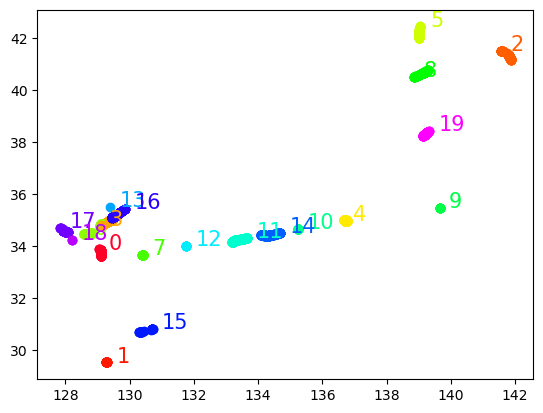

In [279]:
# N台の船の移動
N = 20
NUM_COLORS = N
cm = plt.get_cmap('gist_rainbow')
fig, ax = plt.subplots()
for i in range(N):
    c = cm(1.*i/NUM_COLORS)
    lat = ais_data[(ais_data['Dyn']=='Dyn') & (ais_data['labeled_MMSI']==i)]["Lat"]
    lat = lat.astype(float)
    lon = ais_data[(ais_data['Dyn']=='Dyn') & (ais_data['labeled_MMSI']==i)]["Lon"]
    hdg = ais_data[(ais_data['Dyn']=='Dyn') & (ais_data['labeled_MMSI']==i)]["Hdg"]
    #for j in range(len(lat.values)):
    #    h = float(hdg.values[j])
    #   #ax.arrow(float(lon.values[j]), float(lat.values[j]), float(lon.values[j])+np.cos((90-h)*np.pi/360)*0.01, float(lat.values[j])+np.cos((90-h)*np.pi/360)*0.01)
    #    C = pat.Circle(xy = (float(lon.values[j]), float(lat.values[j])), radius = .1, 
    #           fc = "white", ec = "black", lw = 5)
    #    ax.add_patch(C)
    plt.scatter(x=lon.values, y=lat.values, color=c)
    ax.text(lon.values[0]+0.3, float(lat.values[0]), i, color =c , size = 15)
plt.show()

In [ ]:
#　観測値（シミュレータ）
obs_data = ais_data.values[]

def update(prior, measurement):
    x, P = prior        # 事前分布の平均と分散
    z, R = measurement  # 観測値の平均と分散

    y = z - x        # 残差
    K = P / (P + R)  # カルマンゲイン

    x = x + K*y      # 事後分布の平均
    P = (1 - K) * P  # 事後分布の分散
    return gaussian(x, P)

def predict(posterior, movement):
    x, P = posterior # 事後分布の平均と分散
    dx, Q = movement # 移動量の平均と分散
    x = x + dx
    P = P + Q
    return gaussian(x, P)


obs_std = .13 # 観測の標準偏差
process_var = .05**2 #プロセスの分散
N = len(obs_data) # データ数
zs = obs_data # 観測値
ps = [] # 分散(保存場所)
estimates = [] # 推定値(保存場所)


init_x_mean = 25.
init_x_var = 1000.
x = gaussian(init_x_mean, init_x_var) # 初期状態 観測値を初期状態にすることもある
process_model = gaussian(0., process_var)
for z in zs:
    prior = predict(x, process_model)
    x = update(prior, gaussian(z, obs_std**2))

    # グラフにするために記録する
    estimates.append(x.mean)
    ps.append(x.var)

# フィルタの出力と分散をプロットする
plt.scatter(np.arange(N), zs)
plt.plot(np.arange(N), estimates)
plt.fill_between(np.arange(N), np.array(estimates)-np.array(ps), np.array(estimates)+np.array(ps))
plt.xlabel("step")
plt.ylabel("value")
plt.show()

plt.plot(ps)
plt.title('Variance')
print('Variance converges to {:.3f}'.format(ps[-1]))

x, P = kf.predict(x=10., P=3., u=1., Q=2.**2)
print('%.3f' % x)

x, P = kf.update(x=x, P=P, z=12., R=3.5**2)
print('%.3f' % x, '%.3f' % P)